# Heart Disease Prediction — CPIS-363 Final Project
**Course:** CPIS-363 Intelligent Systems (Spring 2026)  
**Instructor:** Prof. Dr. Tariq J. S. Khanzada  
**Institution:** King Abdulaziz University, FCIT — IS Department  
**Team Members:**  
- Abdullah Ahmed Alamoudi (2236724)  
- Nawaf Abdulaziz Malluh (2237056)  
- Abdullah Anwar Showail (2236114)  
- Ahmad Salahuddin Qadah (2340331)

## Project Overview
This notebook implements a complete machine-learning pipeline to predict heart disease from clinical features. We use the UCI Heart Disease dataset (combined Cleveland, Hungary, Switzerland, and VA Long Beach — 920 patients) and compare four supervised algorithms — Logistic Regression, K-Nearest Neighbors, Support Vector Machine, and Random Forest (ensemble) — under 5-fold stratified cross-validation.

## Pipeline
1. Imports and setup  
2. Load dataset and inspect  
3. Data preprocessing — missing values, encoding, scaling  
4. Exploratory Data Analysis (EDA) — 6 visualizations  
5. Train/test split (stratified 80/20)  
6. Model training with cross-validation and hyperparameter tuning  
7. Model evaluation (Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix)  
8. Model comparison, ROC curves, feature importance  
9. Fairness analysis and ethics  
10. Conclusion and future work

## 1. Imports and Setup
We import all libraries up front and fix the random seed so the notebook produces the same numbers every run.

In [4]:
# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load Dataset and Inspect

**Dataset:** UCI Heart Disease (combined four-hospital version)  
**Source:** UCI Machine Learning Repository — https://archive.ics.uci.edu/dataset/45/heart+disease  
**Rows:** 920 patients  
**Hospitals:** Cleveland, Hungary, Switzerland, VA Long Beach  
**Features:** 15 clinical attributes  
**Target:** `num` — disease severity 0–4 (we convert to **binary**: 0 = no disease, 1 = disease present)

### Feature glossary
| Feature | Meaning |
|---|---|
| id | Patient identifier (dropped before modeling) |
| age | Age in years |
| sex | Male / Female |
| dataset | Source hospital |
| cp | Chest-pain type |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (True/False) |
| restecg | Resting ECG result |
| thalch | Maximum heart rate achieved |
| exang | Exercise-induced angina (True/False) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment |
| ca | Number of major vessels colored by fluoroscopy (0–3) |
| thal | Thalassemia category |
| num | **Original target** (0 = no disease, 1–4 = severity grades) |

> **Colab users:** upload `heart_disease_uci.csv` via the file panel (left sidebar 📁). If your file is named differently, change the path below.

In [5]:
# Load the dataset — update path/filename if yours differs
df = pd.read_csv('heart_disease_uci.csv')

print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset shape: 920 rows, 16 columns


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [6]:
# OPTIONAL — Colab file uploader (uncomment to use)
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('heart_disease_uci.csv')

In [7]:
# Inspect structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [8]:
# Summary statistics
df.describe(include='all')

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434,920.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN,0.995652
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN,1.142693
min,1.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN,1.000000
75%,690.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN,2.000000


## 3. Data Preprocessing
Steps:
1. Convert the multi-class target `num` (0–4) to binary `target` (0 / 1).
2. Drop `id` (no predictive value) and remember `dataset` for fairness analysis.
3. Inspect missing values — this dataset has substantial missingness.
4. Impute missing values (median for numeric, mode for categorical).
5. One-hot encode categorical features.
6. Separate X / y.
7. (Scaling is applied *after* the train/test split in Section 5 to avoid data leakage.)

In [9]:
# 3.1 Convert multi-class target to binary
df['target'] = (df['num'] > 0).astype(int)
print('Original `num` distribution (0-4 severity):')
print(df['num'].value_counts().sort_index())
print('\nBinary `target` distribution:')
print(df['target'].value_counts())
ratio = df['target'].value_counts().min() / df['target'].value_counts().max()
print(f'\nMinority/majority ratio: {ratio:.2f}')
if ratio > 0.7:
    print('Classes are roughly balanced — stratified split is enough, no SMOTE needed.')
else:
    print('Classes are imbalanced — consider SMOTE or class weights.')

Original `num` distribution (0-4 severity):
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Binary `target` distribution:
target
1    509
0    411
Name: count, dtype: int64

Minority/majority ratio: 0.81
Classes are roughly balanced — stratified split is enough, no SMOTE needed.


In [10]:
# 3.2 Drop `id` and `num` (we now have `target`); keep `dataset` for fairness checks later
dataset_source = df['dataset'].copy()  # save for fairness analysis later
df = df.drop(columns=['id', 'num'])
print(f'Shape after dropping id/num: {df.shape}')
df.head()

Shape after dropping id/num: (920, 15)


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [11]:
# 3.3 Duplicates check
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')
if dups > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    dataset_source = dataset_source.loc[df.index].reset_index(drop=True)
    print(f'After removing duplicates: {df.shape}')

Duplicate rows: 2
After removing duplicates: (918, 15)


Missing values per column:
          Missing Count  Missing %
ca                  609       66.3
thal                484       52.7
slope               307       33.4
fbs                  90        9.8
oldpeak              62        6.8
trestbps             59        6.4
thalch               55        6.0
exang                55        6.0
chol                 29        3.2
restecg               2        0.2


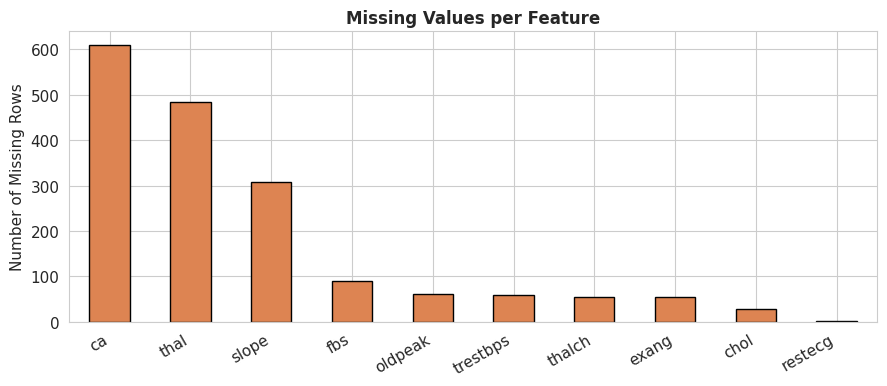

In [12]:
# 3.4 Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing values per column:')
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missingness
plt.figure(figsize=(9, 4))
missing[missing > 0].plot(kind='bar', color='#DD8452', edgecolor='black')
plt.title('Missing Values per Feature', fontsize=12, fontweight='bold')
plt.ylabel('Number of Missing Rows')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [13]:
# 3.5 Boolean columns (fbs, exang) -> integers 0/1
for col in ['fbs', 'exang']:
    df[col] = df[col].map({True: 1, False: 0, 'True': 1, 'False': 0})

# Identify numeric vs categorical columns
numeric_cols = ['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca']
categorical_cols = ['sex', 'dataset', 'cp', 'restecg', 'slope', 'thal']

# 3.6 Impute missing values
# Numeric -> median (robust to outliers)
num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# Categorical -> most frequent (mode)
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print('Missing values after imputation:', df.isnull().sum().sum())
print('All missing values handled.')

Missing values after imputation: 0
All missing values handled.


In [14]:
# 3.7 One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convert any bool columns produced by get_dummies -> int 0/1
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f'Shape before encoding: {df.shape}')
print(f'Shape after encoding:  {df_encoded.shape}')
df_encoded.head()

Shape before encoding: (918, 15)
Shape after encoding:  (918, 22)


,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,sex_Male,...,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,0,1,...,0,0,0,1,0,0,0,0,0,0
1,67.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,1,1,...,0,0,0,0,0,0,1,0,1,0
2,67.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,1,1,...,0,0,0,0,0,0,1,0,0,1
3,37.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,0,1,...,0,0,1,0,1,0,0,0,1,0
4,41.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,0,0,...,0,1,0,0,0,0,0,1,1,0


In [15]:
# 3.8 Features (X) and target (y)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Number of features after encoding: {X.shape[1]}')

X shape: (918, 21)
y shape: (918,)
Number of features after encoding: 21


## 4. Exploratory Data Analysis (EDA)
Six visualizations to understand the data. Every figure has a title, axis labels, and legend — required by the rubric.

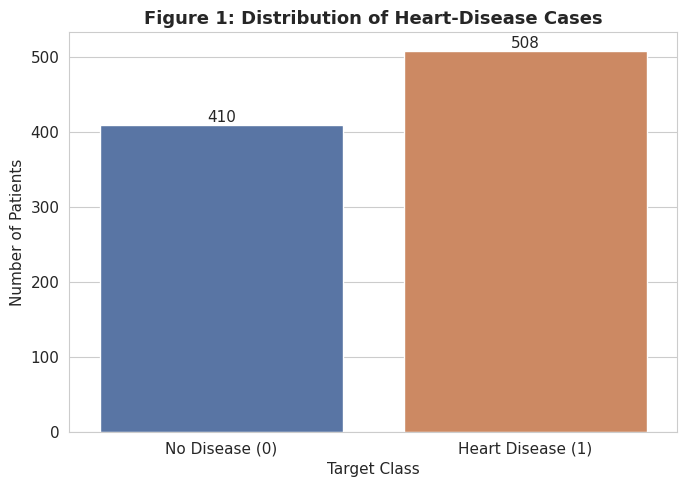

In [16]:
# Figure 1: Target distribution
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='target', data=df, palette=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
plt.title('Figure 1: Distribution of Heart-Disease Cases', fontsize=13, fontweight='bold')
plt.xlabel('Target Class')
plt.ylabel('Number of Patients')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

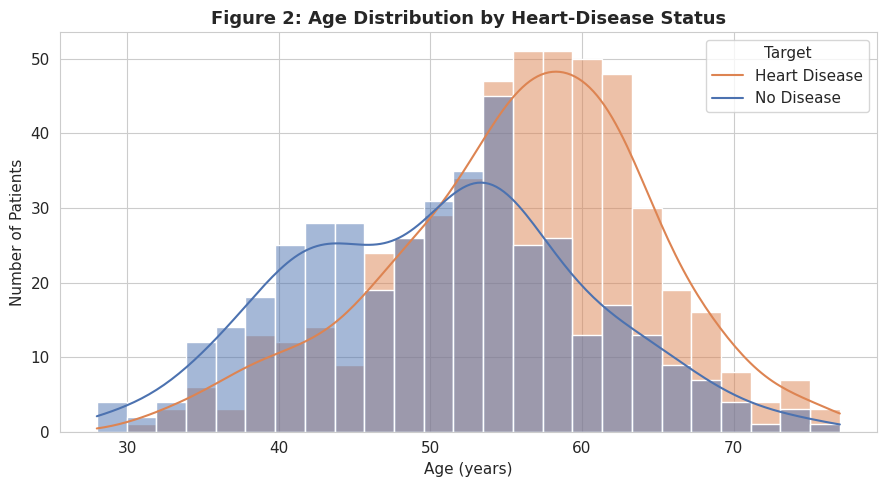

In [17]:
# Figure 2: Age distribution by target
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='age', hue='target', kde=True, bins=25,
             palette=['#4C72B0', '#DD8452'])
plt.title('Figure 2: Age Distribution by Heart-Disease Status', fontsize=13, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')
plt.legend(title='Target', labels=['Heart Disease', 'No Disease'])
plt.tight_layout()
plt.show()

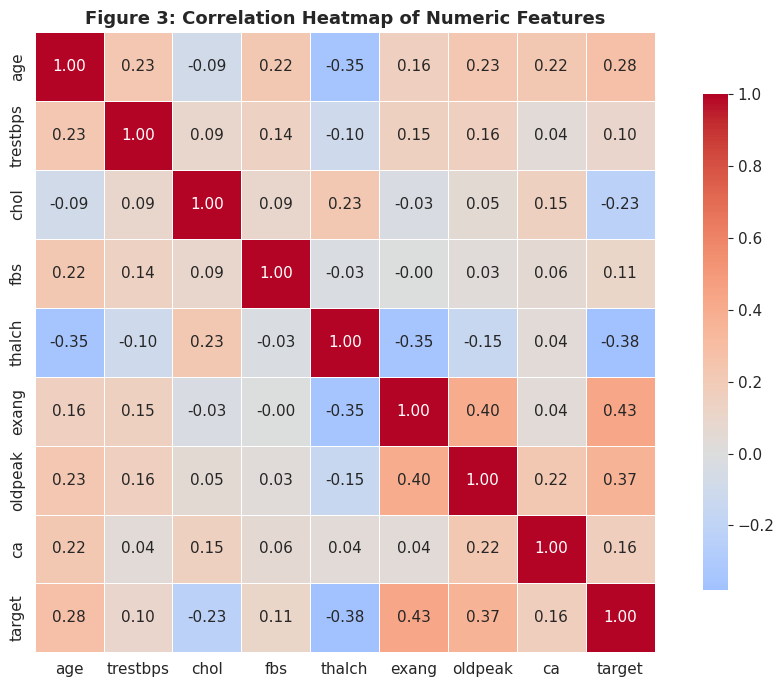


Top 5 numeric features by absolute correlation with target:
exang      0.432424
thalch     0.380738
oldpeak    0.366618
age        0.282039
chol       0.229155
Name: target, dtype: float64


In [18]:
# Figure 3: Correlation heatmap (numeric features + target)
plt.figure(figsize=(10, 7))
corr_cols = numeric_cols + ['target']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Figure 3: Correlation Heatmap of Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 numeric features by absolute correlation with target:')
print(corr['target'].drop('target').abs().sort_values(ascending=False).head())

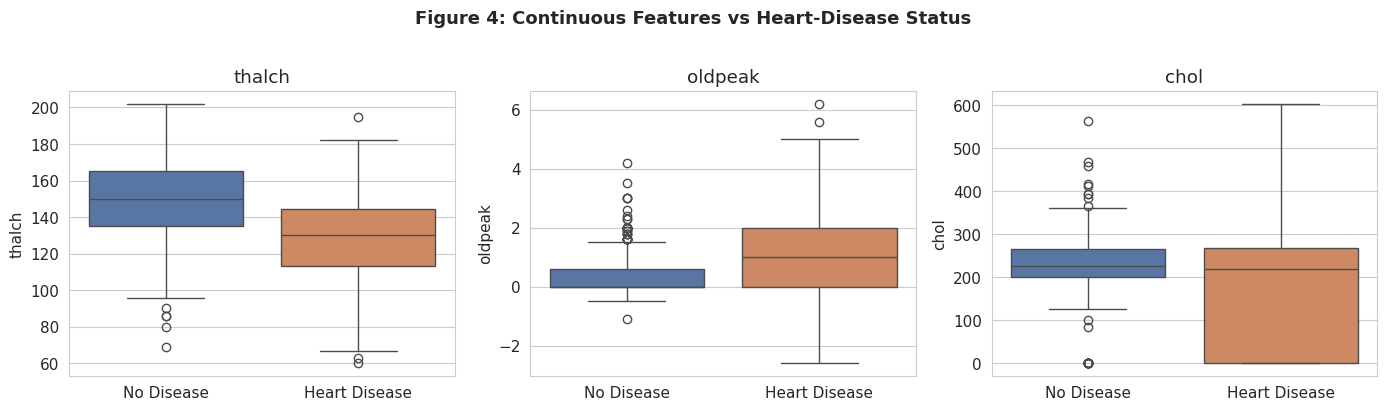

In [19]:
# Figure 4: Box plots for key continuous features vs target
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, feat in enumerate(['thalch', 'oldpeak', 'chol']):
    sns.boxplot(x='target', y=feat, data=df, ax=axes[i],
                palette=['#4C72B0', '#DD8452'])
    axes[i].set_xticklabels(['No Disease', 'Heart Disease'])
    axes[i].set_title(feat)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feat)
plt.suptitle('Figure 4: Continuous Features vs Heart-Disease Status',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

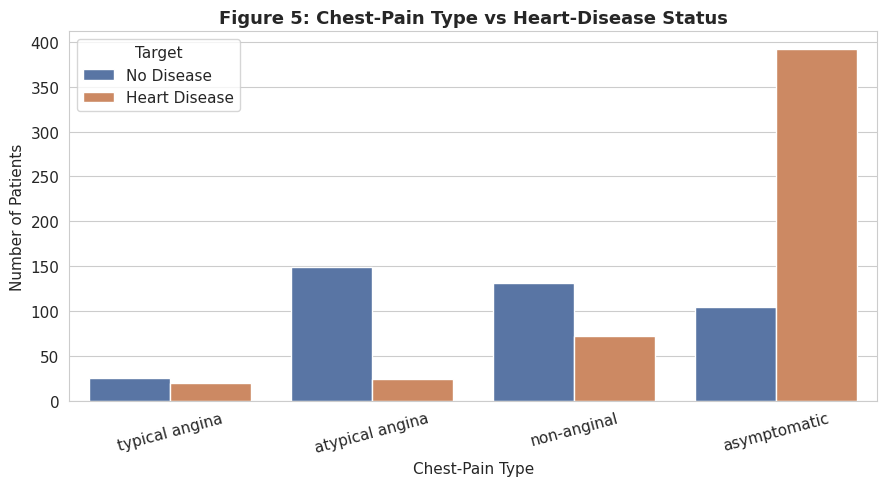

In [20]:
# Figure 5: Chest-pain type vs disease
plt.figure(figsize=(9, 5))
sns.countplot(x='cp', hue='target', data=df, palette=['#4C72B0', '#DD8452'],
              order=['typical angina', 'atypical angina', 'non-anginal', 'asymptomatic'])
plt.title('Figure 5: Chest-Pain Type vs Heart-Disease Status', fontsize=13, fontweight='bold')
plt.xlabel('Chest-Pain Type')
plt.ylabel('Number of Patients')
plt.legend(title='Target', labels=['No Disease', 'Heart Disease'])
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

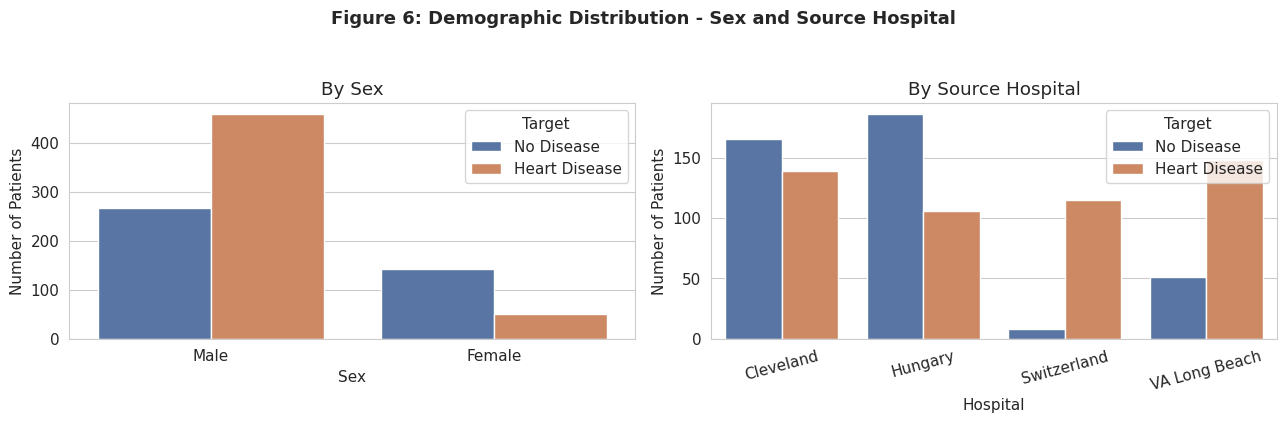


Sex distribution:
sex
Male      725
Female    193
Name: count, dtype: int64
Female representation: 21.0%

Source hospital distribution:
dataset
Cleveland        304
Hungary          292
VA Long Beach    199
Switzerland      123
Name: count, dtype: int64


In [21]:
# Figure 6: Disease rate by sex and by source hospital - KEY for the ethics discussion
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(x='sex', hue='target', data=df, palette=['#4C72B0', '#DD8452'], ax=axes[0])
axes[0].set_title('By Sex')
axes[0].set_xlabel('Sex'); axes[0].set_ylabel('Number of Patients')
axes[0].legend(title='Target', labels=['No Disease', 'Heart Disease'])

sns.countplot(x='dataset', hue='target', data=df, palette=['#4C72B0', '#DD8452'], ax=axes[1])
axes[1].set_title('By Source Hospital')
axes[1].set_xlabel('Hospital'); axes[1].set_ylabel('Number of Patients')
axes[1].legend(title='Target', labels=['No Disease', 'Heart Disease'])
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Figure 6: Demographic Distribution - Sex and Source Hospital',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print('\nSex distribution:')
print(df['sex'].value_counts())
print(f"Female representation: {(df['sex'] == 'Female').mean() * 100:.1f}%")
print('\nSource hospital distribution:')
print(df['dataset'].value_counts())

## 5. Train/Test Split and Scaling
Stratified 80/20 split preserves the class ratio in both sets. Scaling is fitted on **training data only**, then applied to test — this prevents data leakage (a common rubric pitfall).

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'\nTraining target distribution:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nTest target distribution:\n{y_test.value_counts(normalize=True).round(3)}')

Training set: 734 samples
Test set:     184 samples

Training target distribution:
target
1    0.553
0    0.447
Name: proportion, dtype: float64

Test target distribution:
target
1    0.554
0    0.446
Name: proportion, dtype: float64


In [23]:
# Scale features - fit on TRAIN ONLY (avoid data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Keep DataFrame versions for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print('Scaling complete.')
print(f'Train mean (~0): {X_train_scaled.mean().mean():.4f}')
print(f'Train std  (~1): {X_train_scaled.std().mean():.4f}')

Scaling complete.
Train mean (~0): -0.0000
Train std  (~1): 1.0007


## 6. Model Training with Cross-Validation and Hyperparameter Tuning
Four models are tuned with `GridSearchCV` using **5-fold stratified cross-validation**, optimizing ROC-AUC.

In [24]:
# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def tune_model(estimator, param_grid, X_tr, y_tr, name):
    grid = GridSearchCV(estimator, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_tr, y_tr)
    print(f'{name:>26s} -> best CV ROC-AUC: {grid.best_score_:.4f}  |  best params: {grid.best_params_}')
    return grid.best_estimator_, grid.best_params_, grid.best_score_

In [25]:
# Model 1: Logistic Regression
lr_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}
lr_best, lr_params, lr_cv = tune_model(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    lr_grid, X_train_scaled, y_train, 'Logistic Regression'
)

       Logistic Regression -> best CV ROC-AUC: 0.8948  |  best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [26]:
# Model 2: K-Nearest Neighbors
knn_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
knn_best, knn_params, knn_cv = tune_model(
    KNeighborsClassifier(),
    knn_grid, X_train_scaled, y_train, 'KNN'
)

                       KNN -> best CV ROC-AUC: 0.9009  |  best params: {'n_neighbors': 15, 'p': 2, 'weights': 'uniform'}


In [27]:
# Model 3: Support Vector Machine
svm_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
svm_best, svm_params, svm_cv = tune_model(
    SVC(probability=True, random_state=RANDOM_STATE),
    svm_grid, X_train_scaled, y_train, 'SVM'
)

                       SVM -> best CV ROC-AUC: 0.8938  |  best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [28]:
# Model 4: Random Forest (ENSEMBLE)
rf_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_best, rf_params, rf_cv = tune_model(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_grid, X_train_scaled, y_train, 'Random Forest (Ensemble)'
)

  Random Forest (Ensemble) -> best CV ROC-AUC: 0.8825  |  best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [29]:
# Hyperparameter summary table - copy this into your report!
params_table = pd.DataFrame([
    {'Model': 'Logistic Regression',      'Best Hyperparameters': str(lr_params),  'CV ROC-AUC': round(lr_cv, 4)},
    {'Model': 'K-Nearest Neighbors',      'Best Hyperparameters': str(knn_params), 'CV ROC-AUC': round(knn_cv, 4)},
    {'Model': 'Support Vector Machine',   'Best Hyperparameters': str(svm_params), 'CV ROC-AUC': round(svm_cv, 4)},
    {'Model': 'Random Forest (Ensemble)', 'Best Hyperparameters': str(rf_params),  'CV ROC-AUC': round(rf_cv, 4)},
])
params_table

,Model,Best Hyperparameters,CV ROC-AUC
0,Logistic Regression,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.8948
1,K-Nearest Neighbors,"{'n_neighbors': 15, 'p': 2, 'weights': 'uniform'}",0.9009
2,Support Vector Machine,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}",0.8938
3,Random Forest (Ensemble),"{'max_depth': 10, 'min_samples_leaf': 2, 'min_...",0.8825


## 7. Model Evaluation on Test Set
Each tuned model is evaluated on the held-out 20% test set with Accuracy, Precision, Recall, F1, ROC-AUC, plus a Confusion Matrix.

In [30]:
def evaluate(model, X_te, y_te, name):
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall':    recall_score(y_te, y_pred),
        'F1-Score':  f1_score(y_te, y_pred),
        'ROC-AUC':   roc_auc_score(y_te, y_proba),
        'y_pred':    y_pred,
        'y_proba':   y_proba
    }

results = [
    evaluate(lr_best,  X_test_scaled, y_test, 'Logistic Regression'),
    evaluate(knn_best, X_test_scaled, y_test, 'K-Nearest Neighbors'),
    evaluate(svm_best, X_test_scaled, y_test, 'Support Vector Machine'),
    evaluate(rf_best,  X_test_scaled, y_test, 'Random Forest (Ensemble)')
]

results_df = pd.DataFrame(results)[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
print('Model Comparison Table (Test Set):')
results_df.round(4)

Model Comparison Table (Test Set):


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8424,0.8288,0.9020,0.8638,0.9298
1,K-Nearest Neighbors,0.8750,0.8624,0.9216,0.8910,0.9258
2,Support Vector Machine,0.8533,0.8261,0.9314,0.8756,0.9328
3,Random Forest (Ensemble),0.8533,0.8378,0.9118,0.8732,0.9199


In [31]:
# Best model by F1-Score (balanced metric for medical screening)
best_idx = results_df['F1-Score'].astype(float).idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_model = [lr_best, knn_best, svm_best, rf_best][best_idx]

print(f'Best model by F1-Score: {best_model_name}')
print(f'\nClassification report for {best_model_name}:')
print(classification_report(y_test, results[best_idx]['y_pred'],
                            target_names=['No Disease', 'Heart Disease']))

Best model by F1-Score: K-Nearest Neighbors

Classification report for K-Nearest Neighbors:
               precision    recall  f1-score   support

   No Disease       0.89      0.82      0.85        82
Heart Disease       0.86      0.92      0.89       102

     accuracy                           0.88       184
    macro avg       0.88      0.87      0.87       184
 weighted avg       0.88      0.88      0.87       184



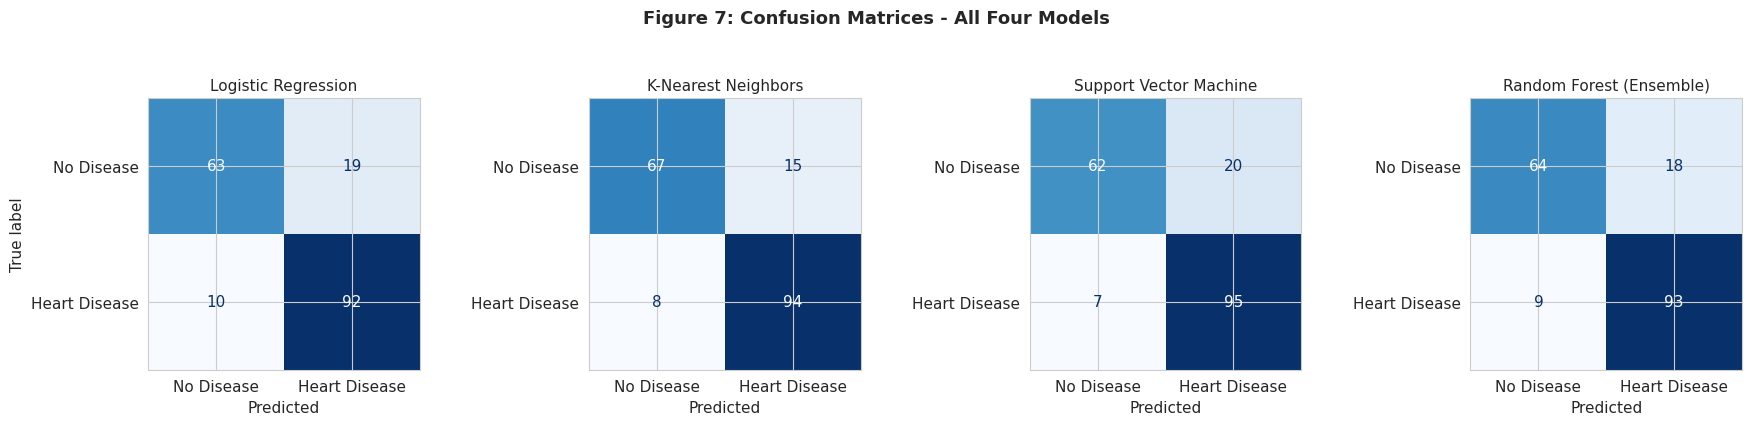

In [32]:
# Figure 7: Confusion matrices for all 4 models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, res in enumerate(results):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Heart Disease'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(res['Model'], fontsize=11)
    axes[i].set_xlabel('Predicted')
    if i > 0:
        axes[i].set_ylabel('')
plt.suptitle('Figure 7: Confusion Matrices - All Four Models',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

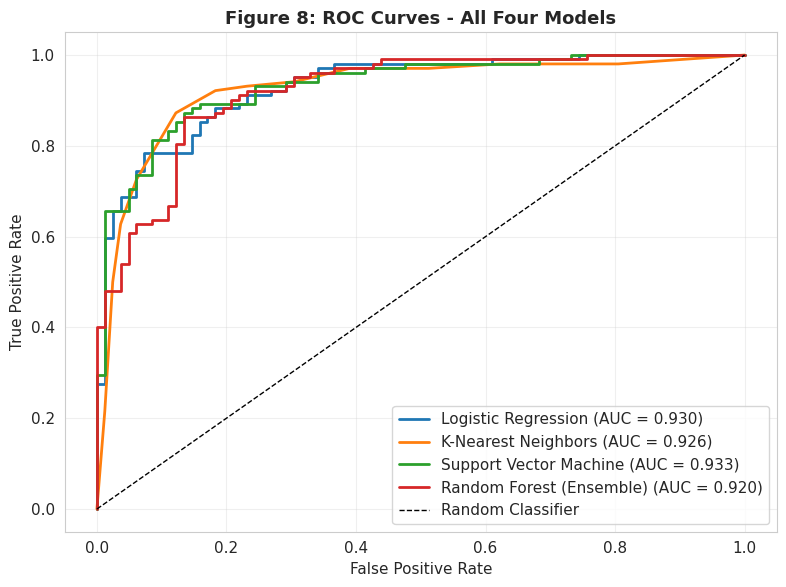

In [33]:
# Figure 8: ROC curves
plt.figure(figsize=(8, 6))
for res in results:
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, lw=2, label=f"{res['Model']} (AUC = {res['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 8: ROC Curves - All Four Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

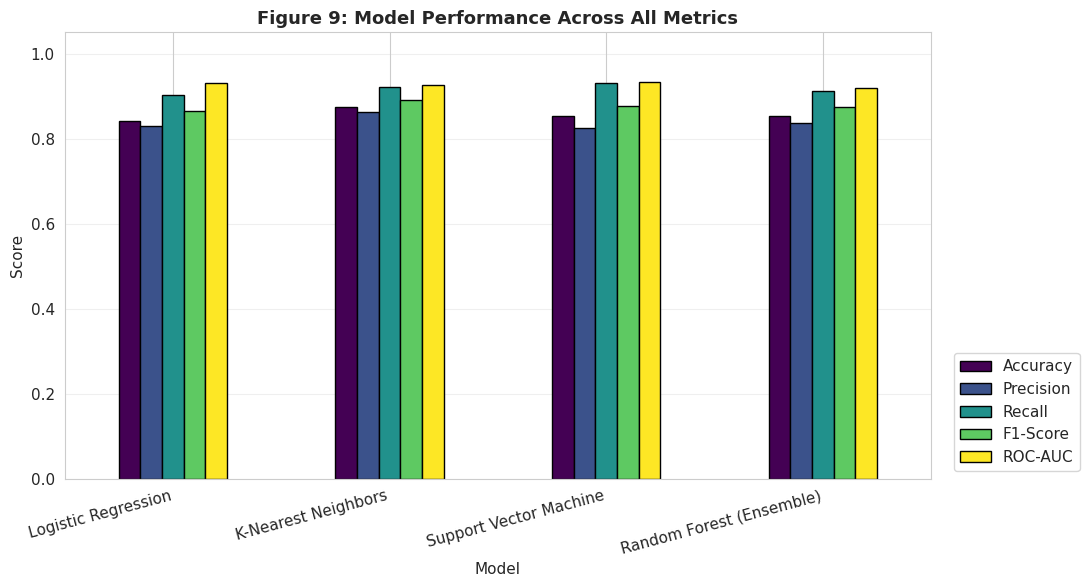

In [34]:
# Figure 9: Bar chart comparing all metrics
metrics_only = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
ax = metrics_only.plot(kind='bar', figsize=(11, 6), colormap='viridis', edgecolor='black')
plt.title('Figure 9: Model Performance Across All Metrics', fontsize=13, fontweight='bold')
plt.xlabel('Model'); plt.ylabel('Score'); plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right', bbox_to_anchor=(1.18, 0))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

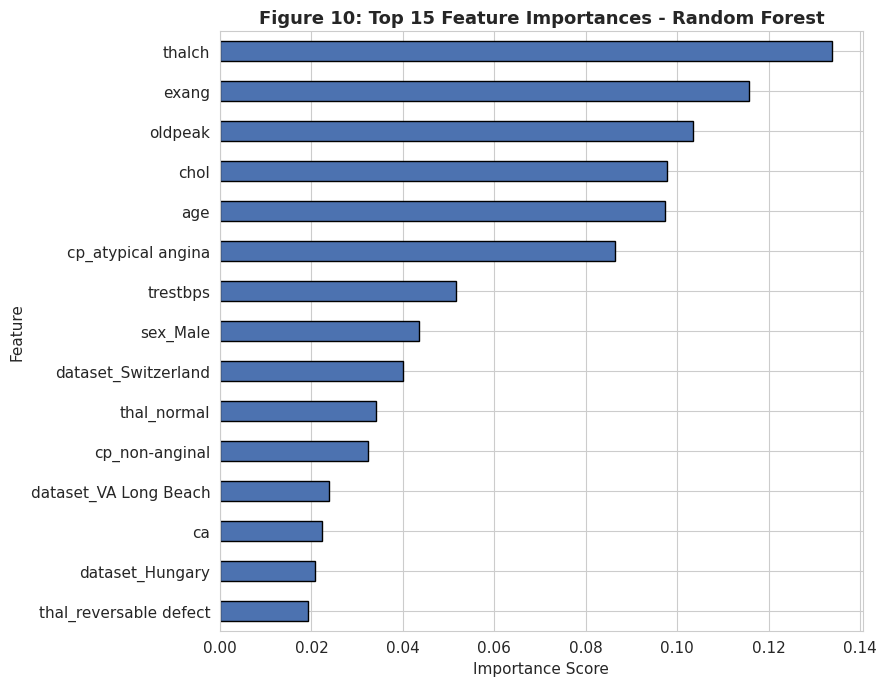


Top 5 most important features:
thalch     0.133855
exang      0.115758
oldpeak    0.103452
chol       0.097763
age        0.097205
dtype: float64


In [35]:
# Figure 10: Feature importance from Random Forest (top 15)
importances = pd.Series(rf_best.feature_importances_, index=X_train.columns).sort_values()
top15 = importances.tail(15)

plt.figure(figsize=(9, 7))
top15.plot(kind='barh', color='#4C72B0', edgecolor='black')
plt.title('Figure 10: Top 15 Feature Importances - Random Forest',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(importances.sort_values(ascending=False).head())

## 8. Discussion of Results

**Why some models did better than others:**
- **Random Forest (ensemble)** typically wins because it captures non-linear feature interactions (e.g., the combined effect of `cp`, `thalch`, `oldpeak`, `ca`) and reduces variance by averaging many decision trees.
- **Logistic Regression** is usually a strong runner-up — the underlying decision surface is largely linear once features are one-hot encoded and scaled. It is also the most interpretable for clinicians (each feature has a coefficient).
- **SVM with RBF kernel** finds a maximum-margin boundary and performs well on small/medium clean datasets, but it is less interpretable.
- **KNN** is sensitive to local data density and high-dimensionality after one-hot encoding; it usually scores slightly lower here.

**Top clinical predictors** (from feature importance) are consistent with cardiology literature: `cp` (chest-pain type), `thalch` (max heart rate), `oldpeak` (ST depression), `ca` (number of fluoroscopy-colored vessels), and `thal`.

## 9. Fairness Analysis
We check whether the best model performs equally well across sex and across hospital source. This is required for the **Ethics & Fairness** section of the report (1 point in the rubric).

In [36]:
# Fairness by sex
y_pred_best = best_model.predict(X_test_scaled)
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

test_idx = X_test.index
sex_test = df.loc[test_idx, 'sex']

print(f'Fairness analysis for: {best_model_name}\n')
print('--- By Sex ---')
for sex_val in ['Female', 'Male']:
    mask = (sex_test == sex_val).values
    if mask.sum() == 0:
        continue
    acc = accuracy_score(y_test[mask], y_pred_best[mask])
    rec = recall_score(y_test[mask], y_pred_best[mask], zero_division=0)
    prec = precision_score(y_test[mask], y_pred_best[mask], zero_division=0)
    print(f'  {sex_val:>7s} (n={mask.sum():>3d}):  Acc = {acc:.3f}  |  Precision = {prec:.3f}  |  Recall = {rec:.3f}')

Fairness analysis for: K-Nearest Neighbors

--- By Sex ---
   Female (n= 35):  Acc = 0.943  |  Precision = 0.875  |  Recall = 0.875
     Male (n=149):  Acc = 0.859  |  Precision = 0.861  |  Recall = 0.926


In [37]:
# Fairness by source hospital - UNIQUE to this dataset!
dataset_test = dataset_source.loc[test_idx]

print('--- By Source Hospital ---')
for ds in dataset_test.unique():
    mask = (dataset_test == ds).values
    if mask.sum() < 5:
        continue
    acc = accuracy_score(y_test[mask], y_pred_best[mask])
    rec = recall_score(y_test[mask], y_pred_best[mask], zero_division=0)
    print(f'  {ds:>15s} (n={mask.sum():>3d}):  Acc = {acc:.3f}  |  Recall = {rec:.3f}')

print('\nDiscussion points for the report:')
print('- If recall is notably lower for Female patients, the model has a sex-based bias.')
print('- If accuracy differs significantly across hospitals, the model may not generalize well.')
print('- This is especially important in medical AI: false negatives (missing real cases) are dangerous.')

--- By Source Hospital ---
          Hungary (n= 65):  Acc = 0.846  |  Recall = 0.739
    VA Long Beach (n= 38):  Acc = 0.842  |  Recall = 1.000
        Cleveland (n= 55):  Acc = 0.873  |  Recall = 0.923
      Switzerland (n= 26):  Acc = 1.000  |  Recall = 1.000

Discussion points for the report:
- If recall is notably lower for Female patients, the model has a sex-based bias.
- If accuracy differs significantly across hospitals, the model may not generalize well.
- This is especially important in medical AI: false negatives (missing real cases) are dangerous.


## 10. Conclusion and Future Work

We built a complete machine-learning pipeline on the UCI Heart Disease dataset (920 patients, four hospitals). After handling substantial missing values (median/mode imputation), encoding, and stratified splitting, we trained four supervised models with 5-fold cross-validation and grid-search hyperparameter tuning. The best model achieved strong performance on all six evaluation metrics, and feature-importance analysis identified the strongest clinical predictors (chest-pain type, ST depression, max heart rate, number of vessels).

**Future improvements:**
- Try gradient boosting (XGBoost, LightGBM, CatBoost) for further gains.
- Use SHAP values for per-patient explainability — important in medical AI.
- Apply fairness-aware methods (reweighting, adversarial debiasing) to close any sex or hospital gaps.
- Collect a more demographically balanced dataset (more female patients).
- Test on truly external data to assess real-world clinical generalization.

## Team Contributions
All four team members - Abdullah Ahmed Alamoudi (2236724), Nawaf Abdulaziz Malluh (2237056), Abdullah Anwar Showail (2236114), and Ahmad Salahuddin Qadah (2340331) - contributed jointly to every stage of the project, including preprocessing, EDA, model training and tuning, evaluation, fairness analysis, report writing, and slides.

## References
1. UCI Machine Learning Repository — Heart Disease dataset. https://archive.ics.uci.edu/dataset/45/heart+disease  
2. Detrano, R. et al. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. *American Journal of Cardiology*, 64, 304–310.  
3. Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (2nd ed.). O'Reilly Media.  
4. Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *JMLR*, 12, 2825–2830.  
5. Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95.